# Particle Filter Analysis

This notebook analyzes particle filter results and studies weight collapse/degeneracy.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set plotting style
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

## 1. Filtering Results with Resampling Markers


In [11]:
# Load stochastic volatility particle filter results
sv_dir = Path('../outputs/stochastic_volatility/stochastic_volatility_pf')

sv_states = np.load(sv_dir / 'states.npy')
sv_means = np.load(sv_dir / 'means.npy')
sv_covs = np.load(sv_dir / 'covs.npy')
sv_obs = np.load(sv_dir / 'observations.npy')
sv_ess = np.load(sv_dir / 'ess.npy')
sv_weights = np.load(sv_dir / 'weights_history.npy')
sv_n_unique = np.load(sv_dir / 'n_unique.npy')
sv_resampled_at = np.load(sv_dir / 'resampled_at.npy')

print("Stochastic Volatility PF Results:")
print(f"  States shape: {sv_states.shape}")
print(f"  Means shape: {sv_means.shape}")
print(f"  ESS shape: {sv_ess.shape}")
print(f"  Weights shape: {sv_weights.shape}")
print(f"  Resampling rate: {len(sv_resampled_at)}/{len(sv_ess)} = {len(sv_resampled_at)/len(sv_ess)*100:.1f}%")

Stochastic Volatility PF Results:
  States shape: (500, 1)
  Means shape: (500, 1)
  ESS shape: (500,)
  Weights shape: (500, 1000)
  Resampling rate: 178/500 = 35.6%


In [12]:
# Load range-bearing particle filter results
rb_dir = Path('../outputs/range_bearing/range_bearing_pf')

rb_states = np.load(rb_dir / 'states.npy')
rb_means = np.load(rb_dir / 'means.npy')
rb_covs = np.load(rb_dir / 'covs.npy')
rb_obs = np.load(rb_dir / 'observations.npy')
rb_ess = np.load(rb_dir / 'ess.npy')
rb_weights = np.load(rb_dir / 'weights_history.npy')
rb_n_unique = np.load(rb_dir / 'n_unique.npy')
rb_resampled_at = np.load(rb_dir / 'resampled_at.npy')

print("\nRange-Bearing PF Results:")
print(f"  States shape: {rb_states.shape}")
print(f"  Means shape: {rb_means.shape}")
print(f"  ESS shape: {rb_ess.shape}")
print(f"  Weights shape: {rb_weights.shape}")
print(f"  Resampling rate: {len(rb_resampled_at)}/{len(rb_ess)} = {len(rb_resampled_at)/len(rb_ess)*100:.1f}%")


Range-Bearing PF Results:
  States shape: (500, 2)
  Means shape: (500, 2)
  ESS shape: (500,)
  Weights shape: (500, 1000)
  Resampling rate: 500/500 = 100.0%


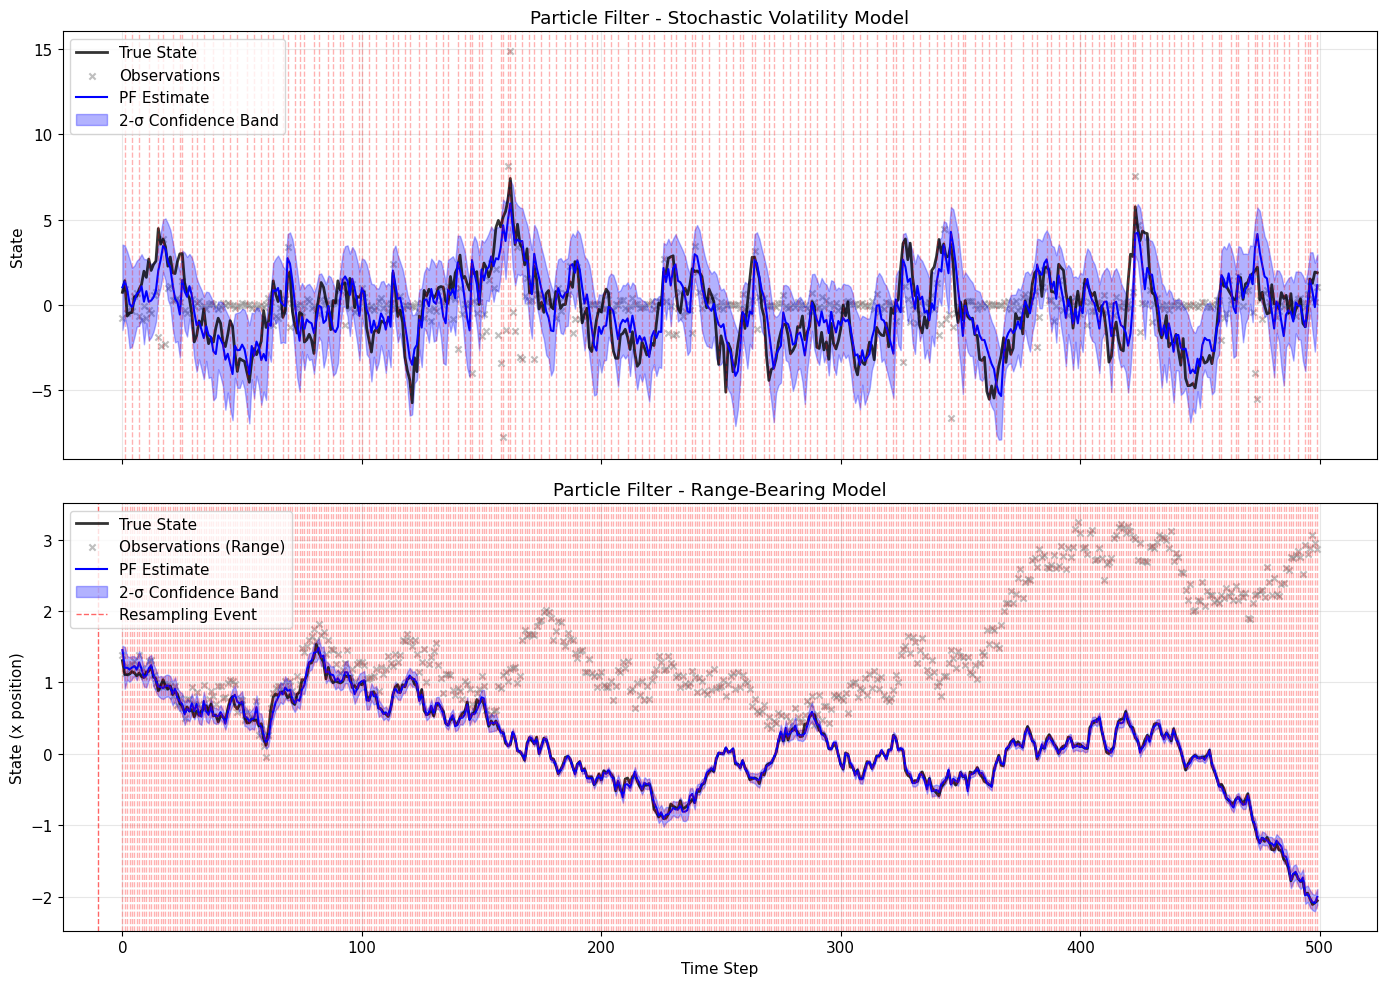

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: Stochastic Volatility
ax = axes[0]
T = len(sv_states)
time_steps = np.arange(T)
std = np.sqrt(sv_covs[:, 0, 0])
upper = sv_means[:, 0] + 2 * std
lower = sv_means[:, 0] - 2 * std

ax.plot(time_steps, sv_states[:, 0], 'k-', linewidth=2, label='True State', alpha=0.8)
ax.scatter(time_steps, sv_obs[:, 0], c='gray', s=20, alpha=0.5, label='Observations', marker='x')
ax.plot(time_steps, sv_means[:, 0], 'b-', linewidth=1.5, label='PF Estimate')
ax.fill_between(time_steps, lower, upper, alpha=0.3, color='blue', label='2-σ Confidence Band')

# Mark resampling events
for t in sv_resampled_at:
    ax.axvline(t, color='red', linestyle='--', alpha=0.3, linewidth=1)

ax.set_ylabel('State')
ax.set_title('Particle Filter - Stochastic Volatility Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Bottom: Range-Bearing
ax = axes[1]
T = len(rb_states)
time_steps = np.arange(T)
std = np.sqrt(rb_covs[:, 0, 0])
upper = rb_means[:, 0] + 2 * std
lower = rb_means[:, 0] - 2 * std

ax.plot(time_steps, rb_states[:, 0], 'k-', linewidth=2, label='True State', alpha=0.8)
ax.scatter(time_steps, rb_obs[:, 0], c='gray', s=20, alpha=0.5, label='Observations (Range)', marker='x')
ax.plot(time_steps, rb_means[:, 0], 'b-', linewidth=1.5, label='PF Estimate')
ax.fill_between(time_steps, lower, upper, alpha=0.3, color='blue', label='2-σ Confidence Band')

# Mark resampling events
for t in rb_resampled_at:
    ax.axvline(t, color='red', linestyle='--', alpha=0.3, linewidth=1)

# Add legend entry for resampling markers
ax.axvline(-10, color='red', linestyle='--', alpha=0.6, linewidth=1, label='Resampling Event')

ax.set_xlabel('Time Step')
ax.set_ylabel('State (x position)')
ax.set_title('Particle Filter - Range-Bearing Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('particle.ipynb1.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Effective Sample Size (ESS) Over Time

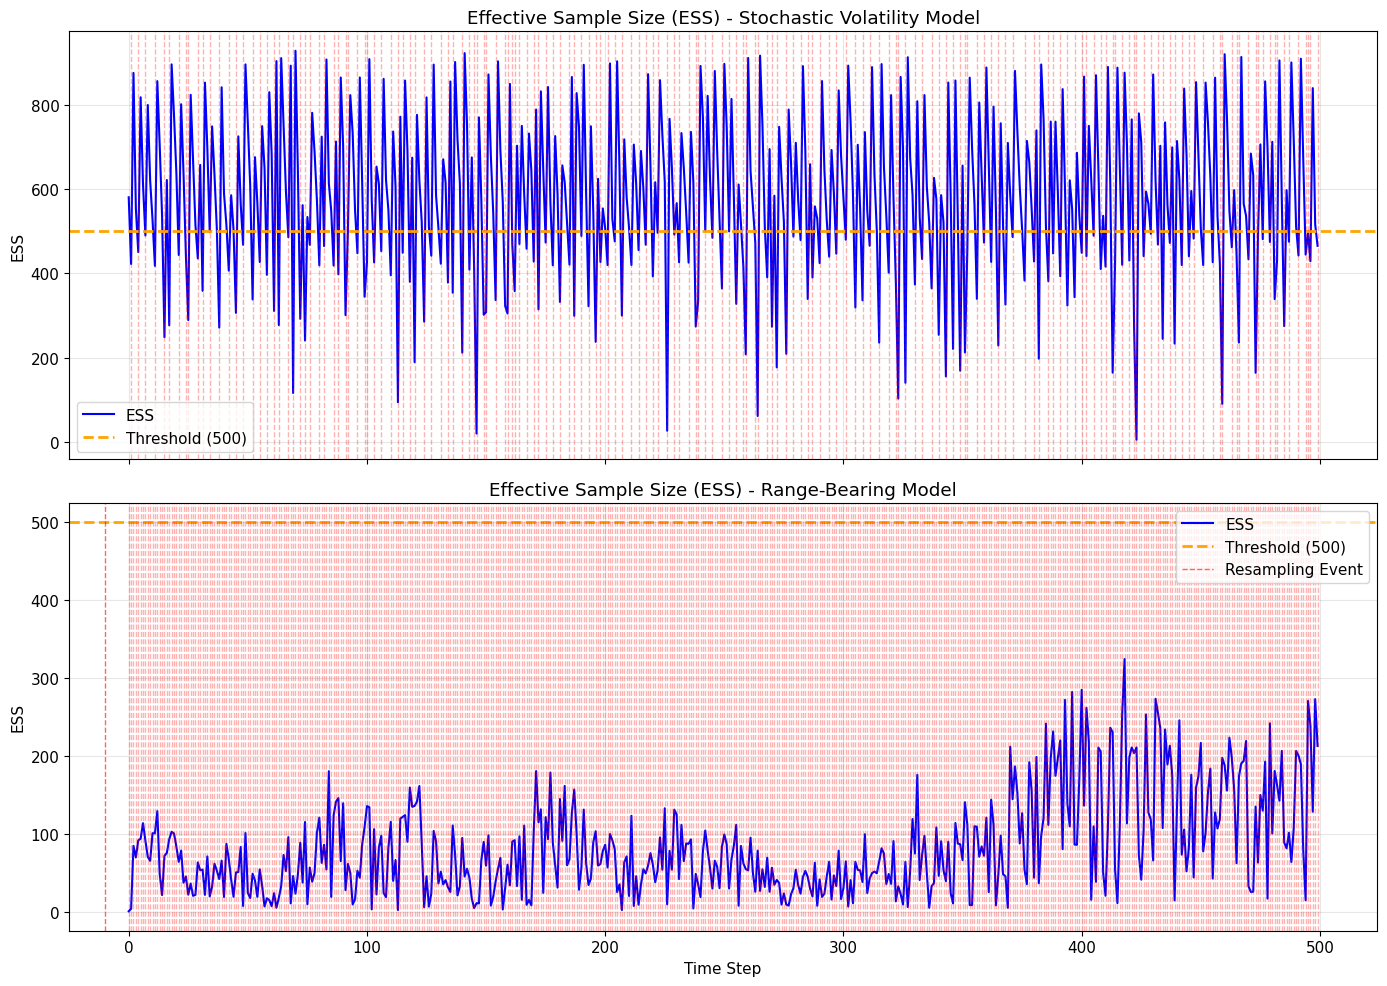

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ESS threshold (0.5 * N_particles = 500)
n_particles = 1000
ess_threshold = 0.5 * n_particles

# Top: Stochastic Volatility
ax = axes[0]
time_steps = np.arange(len(sv_ess))
ax.plot(time_steps, sv_ess, 'b-', linewidth=1.5, label='ESS')
ax.axhline(ess_threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold ({ess_threshold:.0f})')

# Mark resampling events
for t in sv_resampled_at:
    ax.axvline(t, color='red', linestyle='--', alpha=0.3, linewidth=1)

ax.set_ylabel('ESS')
ax.set_title('Effective Sample Size (ESS) - Stochastic Volatility Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Bottom: Range-Bearing
ax = axes[1]
time_steps = np.arange(len(rb_ess))
ax.plot(time_steps, rb_ess, 'b-', linewidth=1.5, label='ESS')
ax.axhline(ess_threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold ({ess_threshold:.0f})')

# Mark resampling events
for t in rb_resampled_at:
    ax.axvline(t, color='red', linestyle='--', alpha=0.3, linewidth=1)

# Add legend entry for resampling markers
ax.axvline(-10, color='red', linestyle='--', alpha=0.6, linewidth=1, label='Resampling Event')

ax.set_xlabel('Time Step')
ax.set_ylabel('ESS')
ax.set_title('Effective Sample Size (ESS) - Range-Bearing Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('particle2.png', dpi=300, bbox_inches='tight')

plt.show()

## 3. Weight Distribution at Selected Timesteps

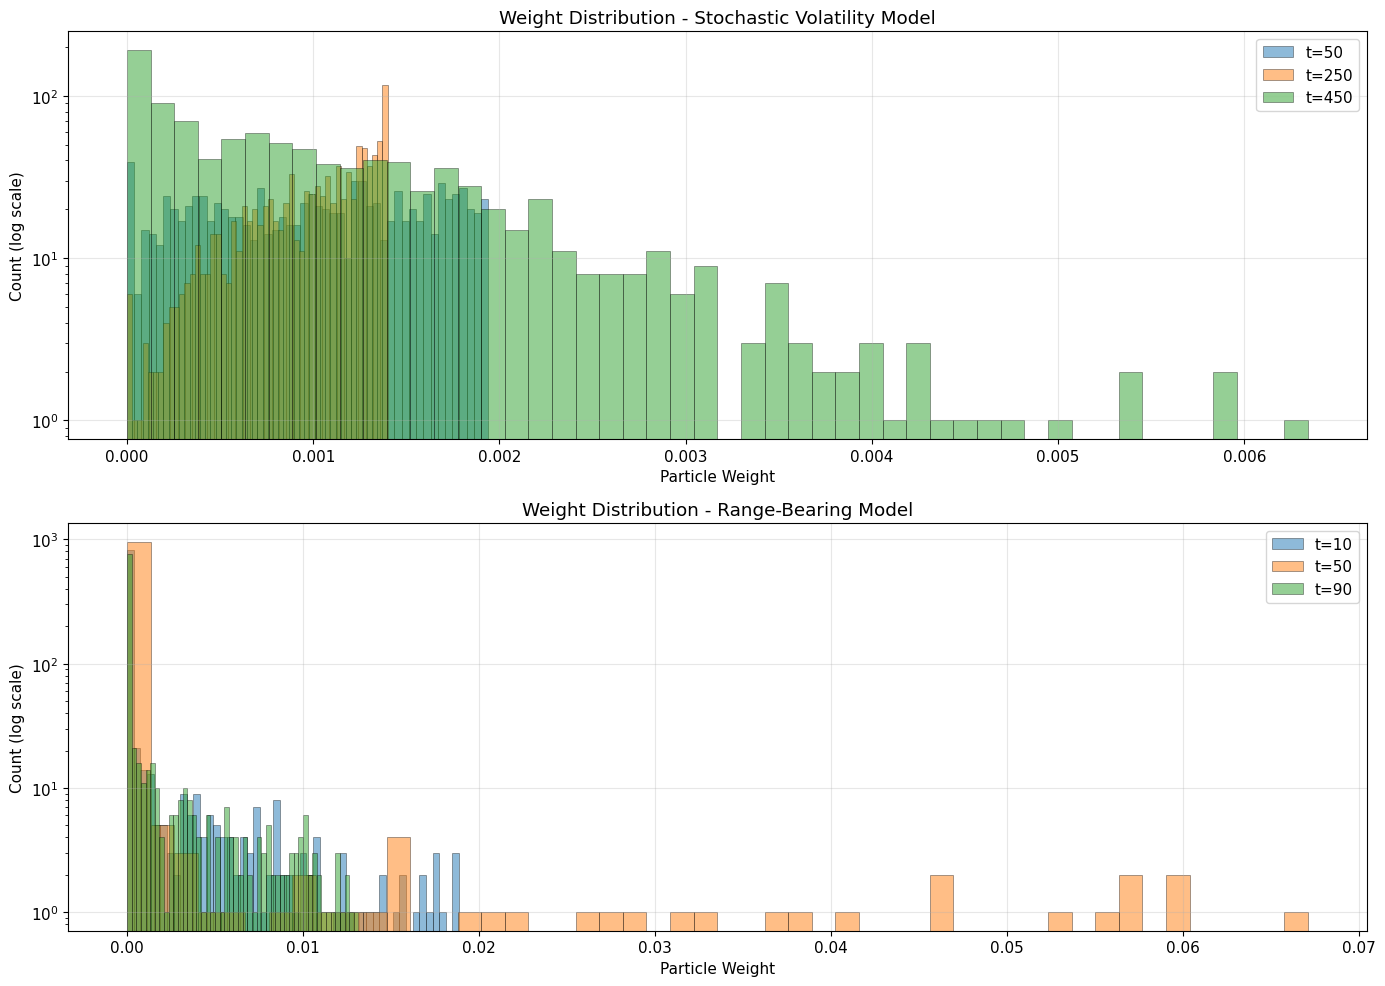

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Select timesteps for visualization (early, middle, late)
sv_timesteps = [50, 250, 450]
rb_timesteps = [10, 50, 90]

# Top: Stochastic Volatility
ax = axes[0]
for t in sv_timesteps:
    weights = sv_weights[t]
    ax.hist(weights, bins=50, alpha=0.5, label=f't={t}', edgecolor='black', linewidth=0.5)

ax.set_yscale('log')
ax.set_xlabel('Particle Weight')
ax.set_ylabel('Count (log scale)')
ax.set_title('Weight Distribution - Stochastic Volatility Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Bottom: Range-Bearing
ax = axes[1]
for t in rb_timesteps:
    weights = rb_weights[t]
    ax.hist(weights, bins=50, alpha=0.5, label=f't={t}', edgecolor='black', linewidth=0.5)

ax.set_yscale('log')
ax.set_xlabel('Particle Weight')
ax.set_ylabel('Count (log scale)')
ax.set_title('Weight Distribution - Range-Bearing Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('particle3.png', dpi=300, bbox_inches='tight')

plt.show()

## 4. Particle Diversity After Resampling

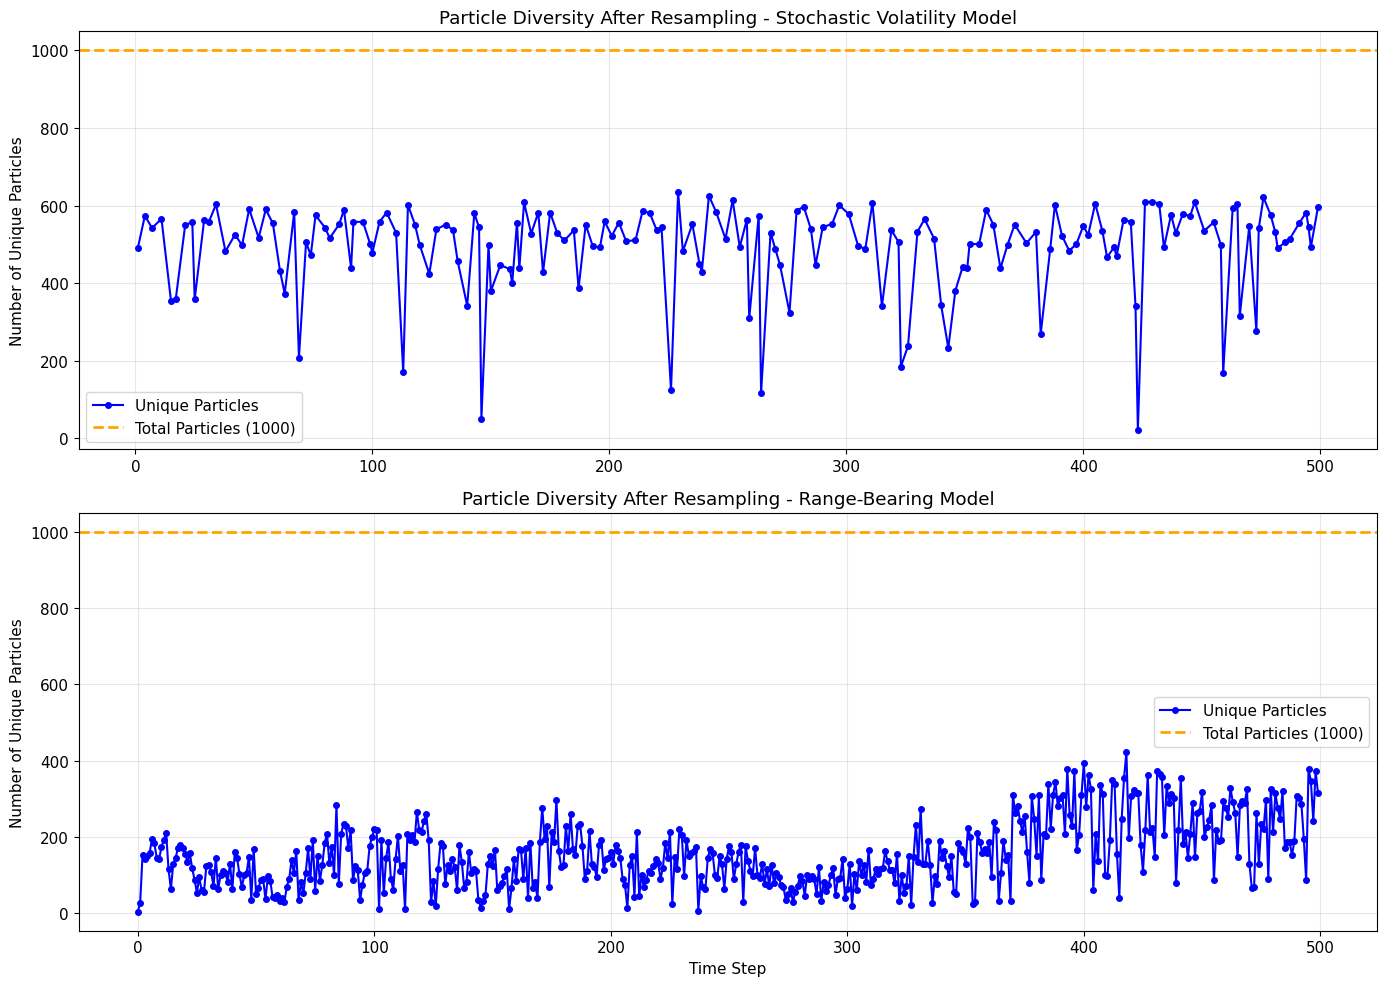

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Stochastic Volatility
ax = axes[0]
ax.plot(sv_resampled_at, sv_n_unique, 'bo-', linewidth=1.5, markersize=4, label='Unique Particles')
ax.axhline(n_particles, color='orange', linestyle='--', linewidth=2, label=f'Total Particles ({n_particles})')

ax.set_ylabel('Number of Unique Particles')
ax.set_title('Particle Diversity After Resampling - Stochastic Volatility Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Bottom: Range-Bearing
ax = axes[1]
ax.plot(rb_resampled_at, rb_n_unique, 'bo-', linewidth=1.5, markersize=4, label='Unique Particles')
ax.axhline(n_particles, color='orange', linestyle='--', linewidth=2, label=f'Total Particles ({n_particles})')

ax.set_xlabel('Time Step')
ax.set_ylabel('Number of Unique Particles')
ax.set_title('Particle Diversity After Resampling - Range-Bearing Model')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('particle4.png', dpi=300, bbox_inches='tight')

plt.show()